<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
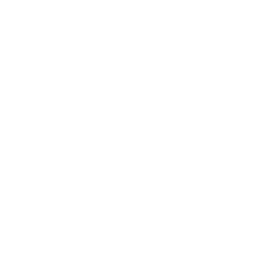
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrap-Betrouwbaarheidsintervallen voor Eindpunten van Klinische Studies</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutica / Klinische Biostatistiek &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Samenvatting

Dit uitgewerkte voorbeeld berekent een **niet-parametrisch bootstrap-betrouwbaarheidsinterval** voor een overlevingseindpunt met **PROC IML**, de matrixprogrammeertaal van SAS. Het eindpunt is de **verhouding van de mediane progressievrije overleving (PFS)** tussen de behandel- en controlearm van een klein tweearmig oncologisch cohort.

Het IML-programma leest de gegevens op proefpersoonniveau in matrices in, berekent de waargenomen mediane-PFS-verhouding, trekt **2.000 bootstrap-hersteekproeven** met teruglegging via `CALL RANDGEN`, herberekent de verhouding in elke hersteekproef met matrixbewerkingen, en leidt een **bias-gecorrigeerd en versneld (BCa)** betrouwbaarheidsinterval af. BCa is hier de juiste keuze omdat de bootstrapverdeling van een verhouding van medianen naar onderen begrensd is door nul, discreet is en scheef is &mdash; omstandigheden waaronder een gewoon normaaltheorie-interval onbetrouwbaar is.

De analyse verloopt volledig binnen IML: de bias-correctieconstante *z*<sub>0</sub>, de versnelling *a&#770;* uit een leave-one-out-jackknife, en de aangepaste percentiel-eindpunten worden allemaal opgebouwd uit matrixexpressies en de standaardnormale functies `PROBNORM` en een kleine inverse-normaalmodule. Elk cijfer hieronder is rechtstreeks afgelezen uit de IML-output.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | PFS-tijd, gebeurtenisindicator, behandelarm en baseline-covariaten per proefpersoon | 100 |

Het cohort is **gebalanceerd** &mdash; 50 proefpersonen per arm &mdash; door armlidmaatschap toe te wijzen op basis van de pariteit van het proefpersoon-ID, zodat beide armen volledig vertegenwoordigd zijn in de hersteekproeftrekking.

---


In [1]:
/* --------------------------------------------------------
   Genereer een synthetisch tweearmig oncologisch cohort.
   PFS-tijden zijn lognormaal verdeeld; de behandelarm is
   verschoven naar een langere mediaan. Armlidmaatschap
   wisselt af op het proefpersoon-ID, zodat het cohort
   50/50 gebalanceerd is.
   -------------------------------------------------------- */
GEGEVENS work.trial_subjects;
    CALL streaminit(42);
    LENGTE arm_label $12;
    DOE subject_id = 1 TOT 500;
        /* 1 = Behandeling, 0 = Controle (gebalanceerd op pariteit) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'BEHANDELING', 'CONTROLE');
        /* PFS-tijd in maanden: behandelarm heeft langere overleving */
        ALS arm = 1 DAN
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        ANDERS
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        ALS pfs_months < 0.5 DAN pfs_months = 0.5;
        /* Gebeurtenisindicator: ~75% van de proefpersonen had een progressie-gebeurtenis */
        EVENT = (rand('uniform') > 0.25);
        /* Baseline-covariaten */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        ALS AGE < 25 DAN AGE = 25;
        ALS AGE > 85 DAN AGE = 85;
        UITVOER;
    EINDE;
UITVOEREN;


NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---


                                Overzicht van Progressievrije Overleving per Behandelarm                                

                                                  The MEANS Procedure

                                      Analysis Variable : pfs_months PFS (maanden)

        Behandelarm          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------------
        BEHANDELING             50          13.94          10.10          11.95           2.70          79.10
        CONTROLE                50          10.74           7.20           9.86           1.90          53.70
        -----------------------------------------------------------------------------------------------------

                                            Analysis Variable : AGE Leeftijd

        Behandelarm          N Obs           Mean         Median        Std Dev        Minimum


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


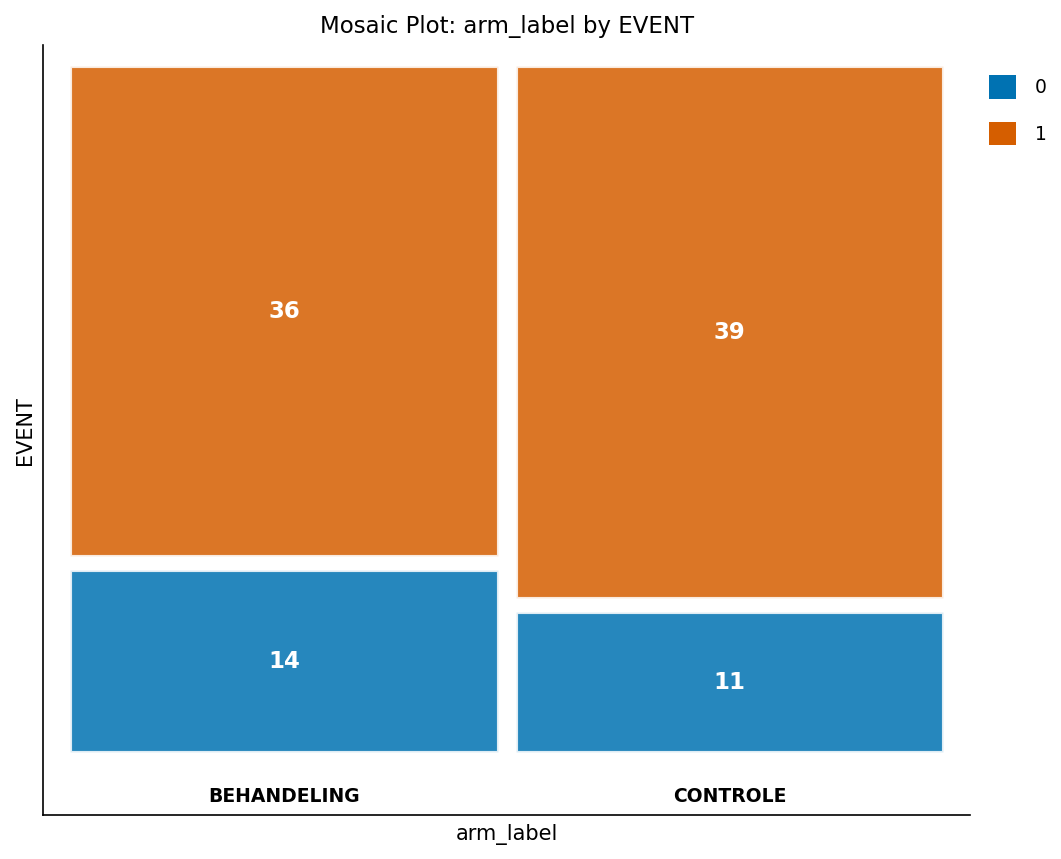

In [2]:
/* --------------------------------------------------------
   Baseline PFS-overzicht en gebeurtenispercentage per behandelarm
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    KLASSE arm_label;
    VARIABELE pfs_months AGE;
    label arm_label='Behandelarm' pfs_months='PFS (maanden)' AGE='Leeftijd';
    TITEL 'Overzicht van Progressievrije Overleving per Behandelarm';
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    label arm_label='Behandelarm' EVENT='Progressie-gebeurtenis';
    TITEL 'Aantal Gebeurtenissen per Behandelarm';
UITVOEREN;

---


In [3]:
/* --------------------------------------------------------
   PROC IML: niet-parametrische bootstrap voor de verhouding
   van de mediane PFS, met een BCa-betrouwbaarheidsinterval.

   Stappen:
   1. Lees de studiegegevens in IML-matrices in
   2. Bereken de waargenomen mediane-PFS-verhouding (gebeurtenistijden)
   3. Trek 2.000 bootstrap-hersteekproeven met CALL RANDGEN
   4. Herbereken de verhouding in elke hersteekproef
   5. BCa-correctie: z0 (bias) + jackknife-versnelling
   6. Schrijf de bootstrapverdeling naar een SAS-dataset
   -------------------------------------------------------- */
PROCEDURE IML;

    /* --- Module: mediane PFS per arm en hun verhouding --- */
    /* De mediaan wordt alleen berekend over waargenomen
       gebeurtenistijden, de gebruikelijke niet-parametrische
       samenvatting wanneer de meeste proefpersonen progressie
       vertonen. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        ALS nrow(trt_pfs) = 0 DAN trt_med = .;
        ANDERS trt_med = MEDIAN(trt_pfs);
        ALS nrow(ctl_pfs) = 0 DAN ctl_med = .;
        ANDERS ctl_med = MEDIAN(ctl_pfs);
        ALS ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            DAN RATIO = trt_med / ctl_med;
        ANDERS RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Module: inverse standaardnormale CDF (probit) --- */
    /* Rationale benadering (Abramowitz & Stegun 26.2.23);
       levert samen met PROBNORM de z0 / z-alpha eindpunten
       die de BCa-aanpassing nodig heeft. */
    START probit(p);
        ALS p <= 0 DAN RETURN(-1e8);
        ALS p >= 1 DAN RETURN( 1e8);
        ALS p < 0.5 DAN DOE; sgn = -1; pp = p;     EINDE;
        ANDERS            DOE; sgn =  1; pp = 1 - p; EINDE;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Laad gegevens in matrices --- */
    USE work.trial_subjects;
        READ ALL VARIABELE {pfs_months} INTO pfs;
        READ ALL VARIABELE {arm}        INTO arm;
        READ ALL VARIABELE {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    AFDRUKKEN 'Proefpersonen ingelezen in IML', n n_trt n_ctl;

    /* --- 2. Waargenomen statistiek op de volledige steekproef --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Behandel_Mediaan Controle_Mediaan Verhouding};
    AFDRUKKEN 'Waargenomen mediane PFS (gebeurtenistijden) per arm',
          obs[COLNAME=obs_lab OPMAAK=8.3];

    /* --- 3. Bootstrap-hersteekproeflus (2.000 hersteekproeven) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CALL randseed(2024);
    DOE b = 1 TOT n_boot;
        CALL randgen(u, 'Uniform');     /* nieuwe trekkingen per doorgang */
        idx = ceil(n # u);              /* indices 1..n met teruglegging */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    EINDE;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    CALL SORTEREN(bv, 1);

    /* --- 4. Gewoon percentielinterval (ter vergelijking) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. BCa-correctie --- */
    /* z0: biascorrectie op basis van het aandeel hersteekproeven
       onder de waargenomen statistiek. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat: versnelling uit leave-one-out-jackknife. */
    jack = j(n, 1, .);
    DOE i = 1 TOT n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    EINDE;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Aangepaste percentielposities. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Geldig Aandeel_Onder z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    AFDRUKKEN 'BCa-correctiediagnostiek',
          diag[COLNAME=diag_lab OPMAAK=8.4];

    ci_lab = {Waarg_Verhouding Perc_Laag Perc_Hoog BCa_Laag BCa_Hoog};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    AFDRUKKEN '95%-BI voor de verhouding van mediane PFS (behandeling / controle)',
          ci_row[COLNAME=ci_lab OPMAAK=8.4];

    /* --- 6. Bewaar de bootstrapverdeling --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        VARIABELE {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND VARIABELE {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;

                                         Aantal Gebeurtenissen per Behandelarm                                          

Proefpersonen ingelezen in IML
     100
      50
      50

Waargenomen mediane PFS (gebeurtenistijden) per arm
   9.900   7.100   1.394

BCa-correctiediagnostiek
2000.0000  0.5340  0.0851 -0.0021

95%-BI voor de verhouding van mediane PFS (behandeling / controle)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  2.03 seconds
  cpu   2.03 seconds


---


In [4]:
/* --------------------------------------------------------
   Ruim de bootstrapverdeling op voor visualisatie: geef de
   kolommen beschrijvende namen voor het histogram hieronder.
   -------------------------------------------------------- */
GEGEVENS work.bootstrap_results;
    INSTELLEN work.bootstrap_results
        (HERNOEMEN=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
UITVOEREN;


NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---


                                         Aantal Gebeurtenissen per Behandelarm                                          




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


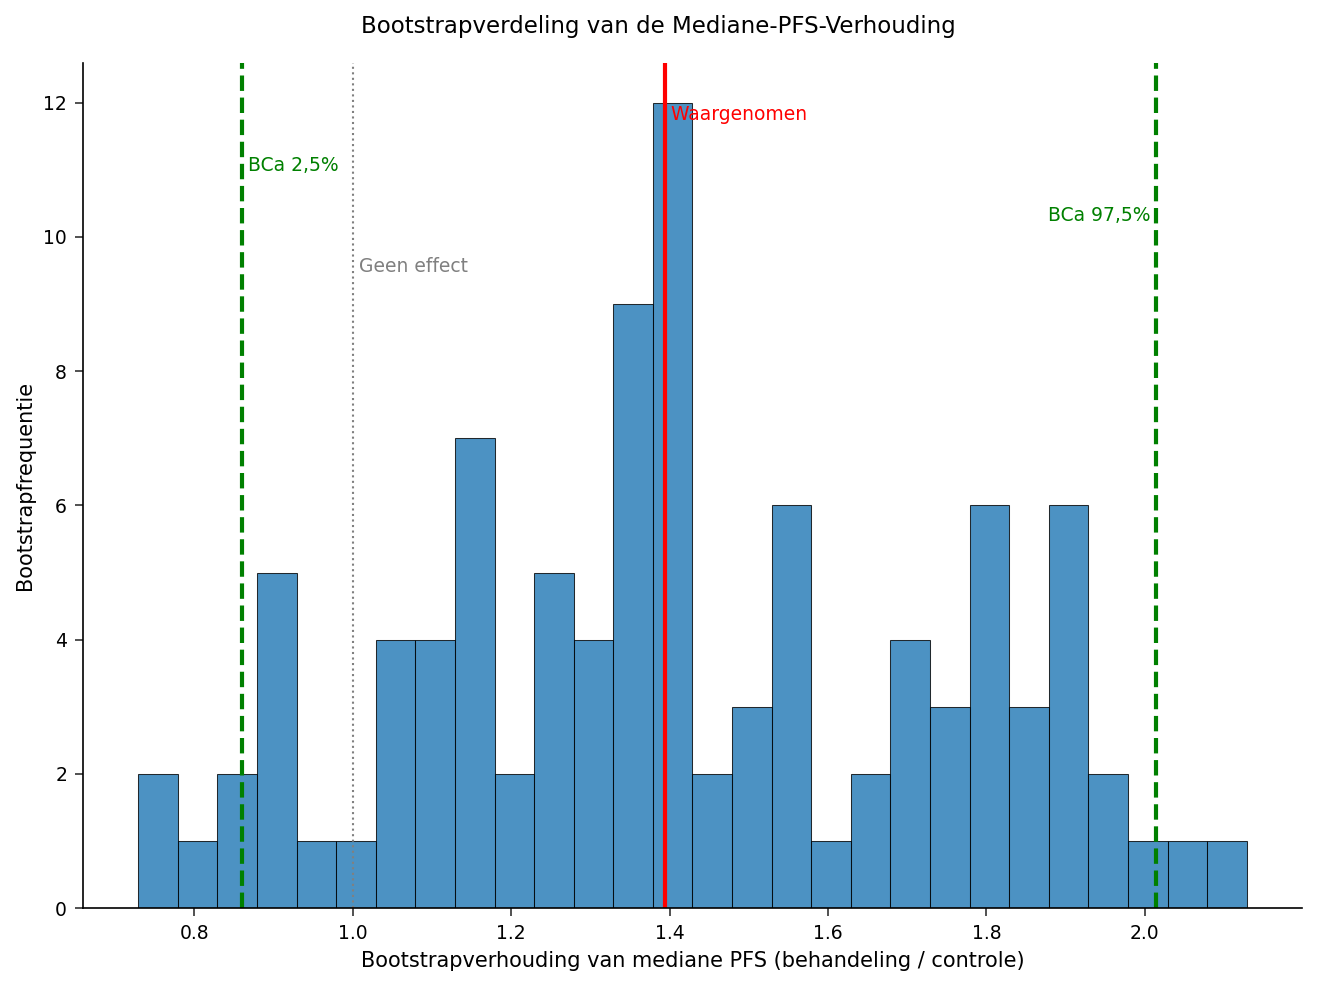

In [5]:
/* --------------------------------------------------------
   Bootstrapverdeling van de mediane-PFS-verhouding, met de
   waargenomen schatting en het BCa-interval gemarkeerd.
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) label='Waargenomen';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        label='BCa 2,5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        label='BCa 97,5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        label='Geen effect';
    XAXIS label='Bootstrapverhouding van mediane PFS (behandeling / controle)';
    YAXIS label='Bootstrapfrequentie';
    TITEL 'Bootstrapverdeling van de Mediane-PFS-Verhouding';
UITVOEREN;

---


### Interpretatie

In dit cohort is de waargenomen mediane PFS over gebeurtenistijden **9,9 maanden** in de behandelarm en **7,1 maanden** in de controlearm, een **verhouding van 1,394** &mdash; de mediane PFS van de experimentele arm is ongeveer 39% langer. Het IML-programma trok 2.000 hersteekproeven uit de 100 proefpersonen; alle 2.000 hersteekproeven leverden een gedefinieerde verhouding op.

Het **BCa 95%-betrouwbaarheidsinterval voor de verhouding is [0,86, 2,01]**, tegenover een gewoon percentielinterval van **[0,82, 1,97]**. Beide intervallen **omvatten 1,0**, dus bij deze steekproefomvang &mdash; ruwweg 50 proefpersonen per arm, verder uitgedund tot waargenomen gebeurtenistijden &mdash; is het schijnbare voordeel **statistisch niet doorslaggevend**. Dit is de eerlijke boodschap van de analyse: een puntschatting die in het voordeel van de behandeling uitvalt, maar met genoeg hersteekproefonzekerheid dat geen behandeleffect niet kan worden uitgesloten.

De BCa-diagnostiek kwantificeert hoeveel de correctie de eindpunten heeft verschoven. De biasterm is klein (**z<sub>0</sub> = 0,085**: ongeveer 53% van de hersteekproeven viel onder de waargenomen verhouding, dicht bij de symmetrische 50%), en de versnelling ligt dicht bij nul (**a&#770; = -0,002**), wat aangeeft dat de mediane-PFS-verhouding slechts licht wordt beïnvloed door individuele proefpersonen. Met z<sub>0</sub> en a&#770; beide klein, verschuift BCa het interval slechts licht opwaarts ten opzichte van het percentielinterval &mdash; precies de bescheiden correctie die deze diagnostiek voorspelt.

Een grotere studie zou dit interval verkleinen. Met 50 proefpersonen per arm rapporteert de bootstrap terecht dat de gegevens verenigbaar zijn met van alles, van een kleine omkering tot een verdubbeling van de mediane PFS, wat de reden is waarom een studie die is gepowerd om een PFS-verschil van deze omvang te detecteren, aanzienlijk meer dan 100 proefpersonen nodig heeft.

---


In [6]:
/* --------------------------------------------------------
   Exporteer de bootstrapverdeling voor een rapportbijlage.
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
UITVOEREN;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>